In [1]:
%%bash
git config --global user.name "Kaggle User"
git config --global user.email "kaggle@example.com"

git config --global user.name
git config --global user.email

Kaggle User
kaggle@example.com


In [2]:
%%bash
pip install -q datalad datalad-installer
datalad-installer --sudo ok git-annex -m datalad/git-annex:release
git-annex version | head -1
datalad --version

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.0/102.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.7/159.7 kB 7.8 MB/s eta 0:00:00
Selecting previously unselected package git-annex-standalone.
(Reading database ... 129802 files and directories currently installed.)
Preparing to unpack .../git-annex-standalone_10.20260901-1.ndall+1_amd64.deb ...
Unpacking git-annex-standalone (10.20260901-1~ndall+1) ...
Setting up git-annex-standalone (10.20260901-1~ndall+1) ...
Processing triggers for hicolor-icon-theme (0.17-2) ...
Processing triggers for man-db (2.12.0-4build2) ...
git-annex version: 10.20260901-1~ndall+1
datalad 1.7.1


2026-10-07T10:05:37+0000 [INFO    ] datalad_installer: Writing environment modifications to /tmp/dl-env-r7t4_o_w.sh
2026-10-07T10:05:37+0000 [INFO    ] datalad_installer: Installing git-annex via datalad/git-annex:release
2026-10-07T10:05:37+0000 [INFO    ] datalad_installer: Version: None
2026-10-07T10:05:38+0000 [WARNING ] datalad_installer: Most recent release of datalad/git-annex lacks asset for this OS; falling back to older releases
2026-10-07T10:05:38+0000 [INFO    ] datalad_installer: Downloading https://github.com/con/git-annex/releases/download/10.20260901/git-annex-standalone_10.20260901-1.ndall%2B1_amd64.deb
2026-10-07T10:05:40+0000 [INFO    ] datalad_installer: Running: sudo dpkg -i /tmp/tmpmy_s4kx4/git-annex-standalone_10.20260901-1.ndall+1_amd64.deb
2026-10-07T10:05:44+0000 [INFO    ] datalad_installer: git-annex is now installed at /usr/bin/git-annex


In [3]:
%%bash
cd /kaggle/working

datalad install https://github.com/CONP-PCNO/conp-dataset.git

install(ok): /kaggle/working/conp-dataset (dataset)


[INFO] Attempting a clone into /kaggle/working/conp-dataset 
[INFO] Attempting to clone from https://github.com/CONP-PCNO/conp-dataset.git to /kaggle/working/conp-dataset 
[INFO] Start enumerating objects 
[INFO] Start counting objects 
[INFO] Start compressing objects 
[INFO] Start receiving objects 
[INFO] Start resolving deltas 
[INFO] Completed clone attempts for Dataset(/kaggle/working/conp-dataset) 
[INFO] Remote origin not usable by git-annex; setting annex-ignore 
[INFO] https://github.com/CONP-PCNO/conp-dataset.git/config download failed: Not Found 


In [4]:
%%bash
cd /kaggle/working/conp-dataset
datalad install projects/calgary-campinas

install(ok): /kaggle/working/conp-dataset/projects/calgary-campinas (dataset) [Installed subdataset in order to get /kaggle/working/conp-dataset/projects/calgary-campinas]


[INFO] Attempting a clone into /kaggle/working/conp-dataset/projects/calgary-campinas 
[INFO] Attempting to clone from https://github.com/conpdatasets/calgary-campinas to /kaggle/working/conp-dataset/projects/calgary-campinas 
[INFO] Start enumerating objects 
[INFO] Start counting objects 
[INFO] Start compressing objects 
[INFO] Start receiving objects 
[INFO] Start resolving deltas 
[INFO] Completed clone attempts for Dataset(/kaggle/working/conp-dataset/projects/calgary-campinas) 
[INFO] Remote origin not usable by git-annex; setting annex-ignore 
[INFO] https://github.com/conpdatasets/calgary-campinas/config download failed: Not Found 


In [5]:
%%bash
cd /kaggle/working/conp-dataset/projects/calgary-campinas

ls

CC359
DATS.json
logo.jpg
README.md


In [6]:
%%bash
cd /kaggle/working/conp-dataset/projects/calgary-campinas/CC359
ls
echo "---"
for d in */; do echo "$d: $(ls "$d" | head -3 | tr '\n' ' ')"; done
echo "---"
find . -maxdepth 2 -name "*.nii*" | head -5

Raw-data
Reconstructed
---
Raw-data/: Multi-channel Single-channel 
Reconstructed/: hippocampus_staple.zip hippocampus_subfields_freesurfer.zip Manual-BEaST-mask-correction.zip 
---


In [7]:
%%bash
cd /kaggle/working/conp-dataset/projects/calgary-campinas/CC359/Reconstructed
ls
echo "-----"
git annex find --include='*' --format='${humansize} ${file}\n'

hippocampus_staple.zip
hippocampus_subfields_freesurfer.zip
Manual-BEaST-mask-correction.zip
Manual.zip
Original.zip
Silver-standard-machine-learning.zip
Silver-standard-STAPLE.zip
-----
2.31 MB Manual-BEaST-mask-correction.zip
1.66 MB Manual.zip
4.15 GB Original.zip
99.52 MB Silver-standard-STAPLE.zip
43.64 MB Silver-standard-machine-learning.zip
3.08 MB hippocampus_staple.zip
2.95 MB hippocampus_subfields_freesurfer.zip


In [8]:
%%bash
cd /kaggle/working/conp-dataset/projects/calgary-campinas/CC359/Reconstructed
datalad get Original.zip Silver-standard-STAPLE.zip

mkdir -p /kaggle/working/CC359
unzip -q -o Original.zip -d /kaggle/working/CC359/Original_zip
unzip -q -o Silver-standard-STAPLE.zip -d /kaggle/working/CC359/STAPLE_zip

cd /kaggle/working/CC359
echo "--- counts (expect 359 volumes)"
find Original_zip -name "*.nii*" | wc -l
find STAPLE_zip -name "*.nii*" | wc -l
echo "--- sample names"
find Original_zip -name "*.nii*" | head -3
find STAPLE_zip -name "*.nii*" | head -5

get(ok): CC359/Reconstructed/Original.zip (file) [from web...]
get(ok): CC359/Reconstructed/Silver-standard-STAPLE.zip (file) [from web...]
action summary:
  get (ok: 2)
--- counts (expect 359 volumes)
359
718
--- sample names
Original_zip/Original/CC0226_siemens_3_64_F.nii.gz
Original_zip/Original/CC0169_siemens_15_44_M.nii.gz
Original_zip/Original/CC0033_philips_15_67_M.nii.gz
STAPLE_zip/STAPLE/CC0034_philips_15_43_F_staple.nii.gz
STAPLE_zip/STAPLE/CC0014_philips_15_62_F_staple.nii.gz
STAPLE_zip/STAPLE/CC0031_philips_15_65_F_staple.nii.gz
STAPLE_zip/STAPLE/CC0351_ge_3_52_M_staple.nii.gz
STAPLE_zip/STAPLE/CC0205_siemens_3_64_F_staple.nii.gz


In [9]:
import nibabel as nib, numpy as np, glob

for suf in ["_staple", "_ss"]:
    f = sorted(glob.glob(f"/kaggle/working/CC359/STAPLE_zip/STAPLE/*{suf}.nii*"))
    print(suf, "files:", len(f))
    if f:
        a = np.asarray(nib.load(f[0]).dataobj)
        print("  ", f[0].split("/")[-1], a.shape, a.dtype,
              "min/max:", a.min(), a.max(), "unique(first 6):", np.unique(a)[:6])

v = sorted(glob.glob("/kaggle/working/CC359/Original_zip/Original/*.nii.gz"))[0]
print("volume:", v.split("/")[-1], nib.load(v).shape)

_staple files: 359
   CC0001_philips_15_55_M_staple.nii.gz (171, 256, 256) float32 min/max: 2.5021002e-15 1.0 unique(first 6): [2.5021002e-15 1.3689905e-11 3.0634592e-11 4.4743011e-11 5.1581781e-11
 6.3554190e-11]
_ss files: 0
volume: CC0001_philips_15_55_M.nii.gz (171, 256, 256)


In [10]:
import glob
from collections import Counter

files = glob.glob(
    "/kaggle/working/CC359/Original_zip/Original/*.nii.gz"
)

groups = []

for f in files:
    name = f.split("/")[-1]
    parts = name.replace(".nii.gz", "").split("_")

    scanner = parts[1]
    field = parts[2]

    groups.append(f"{scanner}_{field}")

counts = Counter(groups)

print("Scanner / field-strength distribution:")
for group, count in sorted(counts.items()):
    print(f"{group:15s}: {count}")

Scanner / field-strength distribution:
ge_15          : 60
ge_3           : 60
philips_15     : 59
philips_3      : 60
siemens_15     : 60
siemens_3      : 60


MRI: CC0001_philips_15_55_M
MRI shape: (171, 256, 256)
Mask shape: (171, 256, 256)
MRI range: 0.0 3030.7017822265625
Mask range: 2.5021002e-15 1.0


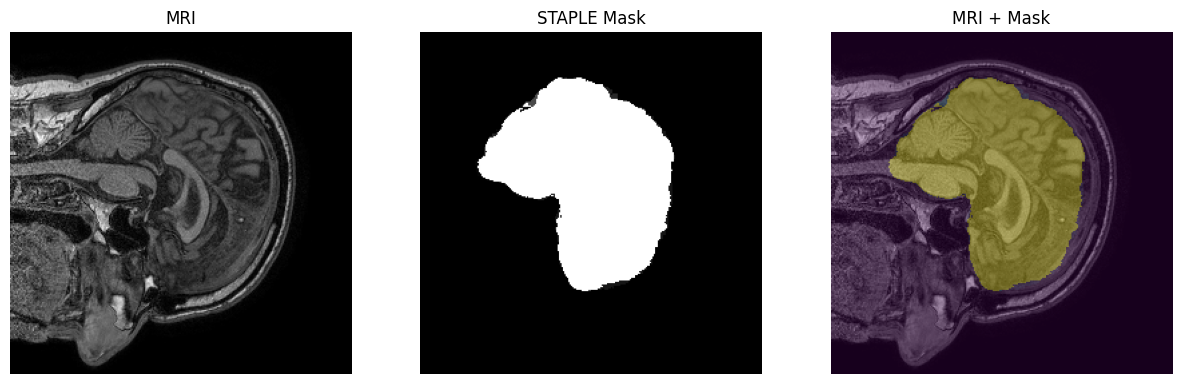

In [11]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# Pick one MRI
mri_path = sorted(
    glob.glob("/kaggle/working/CC359/Original_zip/Original/*.nii.gz")
)[0]

# Corresponding mask
name = os.path.basename(mri_path).replace(".nii.gz", "")
mask_path = f"/kaggle/working/CC359/STAPLE_zip/STAPLE/{name}_staple.nii.gz"

# Load
mri = np.asarray(nib.load(mri_path).dataobj)
mask = np.asarray(nib.load(mask_path).dataobj)

print("MRI:", name)
print("MRI shape:", mri.shape)
print("Mask shape:", mask.shape)
print("MRI range:", mri.min(), mri.max())
print("Mask range:", mask.min(), mask.max())

# Middle slice
z = mri.shape[0] // 2

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(mri[z], cmap="gray")
plt.title("MRI")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask[z], cmap="gray")
plt.title("STAPLE Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(mri[z], cmap="gray")
plt.imshow(mask[z], alpha=0.35)
plt.title("MRI + Mask")
plt.axis("off")

plt.show()

In [10]:
import os, glob, re, random
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import nibabel as nib
from torch.utils.data import Dataset, DataLoader

class CC359Dataset(Dataset):
    def __init__(self, vol_paths, mask_paths=None, size=256, axis=0, keep_empty=True):
        self.size, self.vols, self.masks, self.items = size, [], [], []
        for i, vp in enumerate(vol_paths):
            v = np.asarray(nib.load(vp).dataobj, dtype=np.float32)
            nz = v > 0
            v = (v - v[nz].mean()) / (v[nz].std() + 1e-6)        # per-scan z-score
            self.vols.append(np.moveaxis(v, axis, 0).astype(np.float16))
            m = None
            if mask_paths is not None:
                m = np.asarray(nib.load(mask_paths[i]).dataobj) > 0.5   # STAPLE probability -> binary
                m = np.moveaxis(m, axis, 0).astype(np.uint8)
            self.masks.append(m)
            for s in range(self.vols[-1].shape[0]):
                if keep_empty or m is None or m[s].any():
                    self.items.append((i, s))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, k):
        i, s = self.items[k]
        img = torch.from_numpy(self.vols[i][s].astype(np.float32))[None, None]
        img = F.interpolate(img, size=(self.size,) * 2, mode="bilinear", align_corners=False)[0]
        if self.masks[i] is None:
            return img
        m = torch.from_numpy(self.masks[i][s].astype(np.float32))[None, None]
        m = F.interpolate(m, size=(self.size,) * 2, mode="nearest")[0]
        return img, m

In [11]:
IMG_GLOB  = "/kaggle/working/CC359/Original_zip/Original/*.nii.gz"
MASK_GLOB = "/kaggle/working/CC359/STAPLE_zip/STAPLE/*_staple.nii.gz"

def subject_id(p): return re.search(r"CC\d{4}", os.path.basename(p)).group(0)
def domain_of(p):
    parts = os.path.basename(p).split("_")      # CC0001_philips_15_55_M.nii.gz
    return parts[1], parts[2]                   # (vendor, field)

mask_by_id = {subject_id(p): p for p in glob.glob(MASK_GLOB)}
domains = {}
for p in sorted(glob.glob(IMG_GLOB)):
    domains.setdefault(domain_of(p), []).append((p, mask_by_id[subject_id(p)]))
print({k: len(v) for k, v in domains.items()})

def split_items(items, fracs, seed=42):
    items = items[:]; random.Random(seed).shuffle(items)
    n = len(items); i = int(n * fracs[0]); j = i + int(n * fracs[1])
    return items[:i], items[i:j], items[j:]

src_tr, src_va, src_te = split_items(domains[("ge", "3")],      (0.8, 0.1))
tgt_tr, tgt_va, tgt_te = split_items(domains[("philips", "3")], (0.7, 0.15))

def make_ds(items):
    return CC359Dataset([p for p, _ in items], [m for _, m in items])

src_train_ds, src_val_ds, src_test_ds = make_ds(src_tr), make_ds(src_va), make_ds(src_te)
tgt_train_ds, tgt_val_ds, tgt_test_ds = make_ds(tgt_tr), make_ds(tgt_va), make_ds(tgt_te)  # tgt_train_ds is only for the oracle

BS = 8
src_train_loader = DataLoader(src_train_ds, batch_size=BS, shuffle=True, drop_last=True, num_workers=2)
src_val_loader   = DataLoader(src_val_ds,   batch_size=BS, shuffle=False, num_workers=2)
print("slices:", len(src_train_ds), len(src_val_ds), len(src_test_ds), len(tgt_test_ds))

{('philips', '15'): 59, ('philips', '3'): 60, ('siemens', '15'): 60, ('siemens', '3'): 60, ('ge', '15'): 60, ('ge', '3'): 60}
slices: 9476 1168 1148 1620


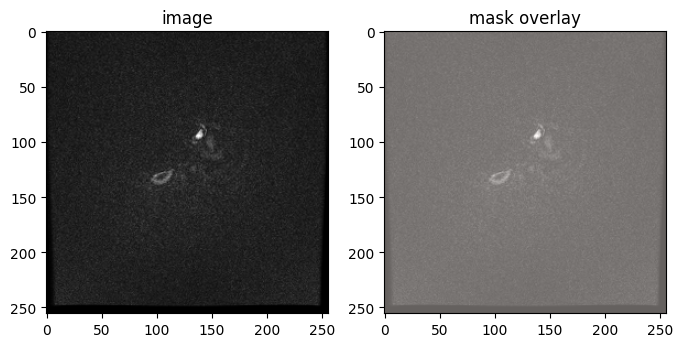

torch.Size([1, 256, 256]) torch.Size([1, 256, 256]) mask fraction: 0.0


In [12]:
import matplotlib.pyplot as plt
x, y = src_train_ds[len(src_train_ds) // 2]
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(x[0], cmap="gray"); ax[0].set_title("image")
ax[1].imshow(x[0], cmap="gray"); ax[1].imshow(y[0], alpha=0.4, cmap="Reds"); ax[1].set_title("mask overlay")
plt.show()
print(x.shape, y.shape, "mask fraction:", y.mean().item())

In [16]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(8, out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(8, out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)
        

test_block = DoubleConv(in_channels=1, out_channels=16)
test_input = torch.randn(8, 1, 256, 256)
test_output = test_block(test_input)
print("Output shape:", test_output.shape)   

Output shape: torch.Size([8, 16, 256, 256])


In [17]:
class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(256, 512)

        # Decoder
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x, return_features=False):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        logits = self.final(d1)

        if return_features:
            # (256ch @32x32, 512ch @16x16, 256ch @32x32)
            return logits, (e3, b, d3)

        return logits





In [15]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(in_channels=1, out_channels=1).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train_model(model,loader,optimizer,criterion,device):
  model.train()
  total_loss =0
  for batch_idx, (images,masks) in enumerate(loader):
    images =images.to(device)
    masks = masks.to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs,masks)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()


  avg_loss =total_loss/len(loader)
  return avg_loss


In [18]:
def validate_model(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            total_loss += loss.item()
    return total_loss / len(loader)


In [19]:
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def dice_loss(logits, masks, eps=1.0):
    p = torch.sigmoid(logits)
    inter = (p * masks).sum(dim=(1, 2, 3))
    den = p.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3))
    return 1 - ((2 * inter + eps) / (den + eps)).mean()

bce = nn.BCEWithLogitsLoss()
def seg_loss(logits, masks): return bce(logits, masks) + dice_loss(logits, masks)

model = UNet(in_channels=1, out_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
NUM_EPOCHS, PATIENCE = 20, 5
BEST_PATH = "/kaggle/working/src_only_best.pth"
best_val, bad = float("inf"), 0

for epoch in range(NUM_EPOCHS):
    tr = train_model(model, src_train_loader, optimizer, seg_loss, device)
    va = validate_model(model, src_val_loader, seg_loss, device)
    improved = va < best_val
    if improved:
        best_val, bad = va, 0
        torch.save(model.state_dict(), BEST_PATH)
    else:
        bad += 1
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - train {tr:.4f}, val {va:.4f}" + ("  <- saved" if improved else ""))
    if bad >= PATIENCE:
        print("Early stop"); break

In [34]:
@torch.no_grad()
def evaluate_volumes(model, ds, device, bs=16, thr=0.5):
    model.eval()
    by_vol = {}
    for k, (i, s) in enumerate(ds.items):
        by_vol.setdefault(i, []).append(k)
    dices, ious = [], []
    for i, idxs in by_vol.items():
        P, G = [], []
        for j in range(0, len(idxs), bs):
            batch = [ds[k] for k in idxs[j:j + bs]]
            x = torch.stack([b[0] for b in batch]).to(device)
            G.append(torch.stack([b[1] for b in batch]))
            P.append((torch.sigmoid(model(x)).cpu() > thr).float())
        p, g = torch.cat(P), torch.cat(G)
        inter = (p * g).sum().item()
        dices.append(2 * inter / (p.sum().item() + g.sum().item() + 1e-8))
        ious.append(inter / (((p + g) > 0).sum().item() + 1e-8))
    return {"dice": float(np.mean(dices)), "dice_std": float(np.std(dices)),
            "iou": float(np.mean(ious)), "n_volumes": len(dices)}


In [ ]:
model.load_state_dict(torch.load(BEST_PATH, map_location=device))
r_src = evaluate_volumes(model, src_test_ds, device)
r_tgt = evaluate_volumes(model, tgt_test_ds, device)
print("GE 3T (source) test:     ", r_src)
print("Philips 3T (target) test:", r_tgt)
print("Dice drop:", round(r_src["dice"] - r_tgt["dice"], 4))

In [ ]:
torch.manual_seed(42)
oracle = UNet(in_channels=1, out_channels=1).to(device)
opt = torch.optim.Adam(oracle.parameters(), lr=1e-3)

tgt_train_loader = DataLoader(tgt_train_ds, batch_size=8, shuffle=True, drop_last=True, num_workers=2)
tgt_val_loader   = DataLoader(tgt_val_ds,   batch_size=8, shuffle=False, num_workers=2)

ORACLE_PATH = "/kaggle/working/oracle_best.pth"
NUM_EPOCHS, PATIENCE = 20, 5          # same budget as the source-only model
best_val, bad = float("inf"), 0

for epoch in range(NUM_EPOCHS):
    tr = train_model(oracle, tgt_train_loader, opt, seg_loss, device)
    va = validate_model(oracle, tgt_val_loader, seg_loss, device)
    improved = va < best_val
    if improved:
        best_val, bad = va, 0
        torch.save(oracle.state_dict(), ORACLE_PATH)
    else:
        bad += 1
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - train {tr:.4f}, val {va:.4f}" + ("  <- saved" if improved else ""))
    if bad >= PATIENCE:
        print("Early stop"); break

oracle.load_state_dict(torch.load(ORACLE_PATH, map_location=device))
r_orc = evaluate_volumes(oracle, tgt_test_ds, device)
print(f"Oracle on Philips 3T test | volumes: {r_orc['n_volumes']} | Dice: {r_orc['dice']:.4f} ± {r_orc['dice_std']:.4f} | IoU: {r_orc['iou']:.4f}")

In [ ]:
import zipfile

files = [
    "/kaggle/working/oracle_best.pth",
    "/kaggle/working/src_only_best.pth"
]

with zipfile.ZipFile("/kaggle/working/cc359_models.zip", "w") as z:
    for f in files:
        z.write(f, arcname=f.split("/")[-1])

print("Created: /kaggle/working/cc359_models.zip")

In [ ]:
!curl -F "file=@/kaggle/working/oracle_best.pth" https://tmpfiles.org/api/v1/upload
!curl -F "file=@/kaggle/working/src_only_best.pth" https://tmpfiles.org/api/v1/upload

In [20]:
# start of DANN

import torch
import torch.nn as nn
from torch.autograd import Function

class GradientReversalFunction(Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.alpha * grad_output, None

class GradientReversalLayer(nn.Module):
    def __init__(self, alpha=1.0):
        super().__init__()
        self.alpha = alpha

    def forward(self, x):
        return GradientReversalFunction.apply(x, self.alpha)

In [21]:
x = torch.tensor([2.0], requires_grad=True)
grl = GradientReversalLayer(alpha=1.0)
y = grl(x) * 3
y.backward()
print("x.grad:", x.grad)

x.grad: tensor([-3.])


In [22]:
class DomainClassifier(nn.Module):
    def __init__(self, in_channels=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 128, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 1, 1),
        )

    def forward(self, x):
        return self.net(x)

In [23]:
class DomainHead(nn.Module):
    def __init__(self, channels=(256, 512, 256), alpha=1.0):
        super().__init__()
        self.grl = GradientReversalLayer(alpha)
        self.heads = nn.ModuleList([DomainClassifier(c) for c in channels])

    def forward(self, feats):
        return [h(self.grl(f)) for f, h in zip(feats, self.heads)]


def domain_loss_fn(src_preds, tgt_preds, criterion):
    loss = 0
    for ps, pt in zip(src_preds, tgt_preds):
        loss += (criterion(ps, torch.zeros_like(ps)) +
                 criterion(pt, torch.ones_like(pt))) / 2
    return loss / len(src_preds)



In [24]:
domain_head = DomainHead(channels=(256, 512, 256), alpha=1.0)

model = UNet(in_channels=1, out_channels=1)

test_input = torch.randn(2, 1, 256, 256)

segmentation, features = model(test_input, return_features=True)
domain_logits = domain_head(features)

print("Segmentation:", segmentation.shape)
print("Features:", [f.shape for f in features])
print("Domain logits:", [d.shape for d in domain_logits])

Segmentation: torch.Size([2, 1, 256, 256])
Features: [torch.Size([2, 256, 64, 64]), torch.Size([2, 512, 32, 32]), torch.Size([2, 256, 64, 64])]
Domain logits: [torch.Size([2, 1, 64, 64]), torch.Size([2, 1, 32, 32]), torch.Size([2, 1, 64, 64])]


In [25]:
def setup_training(model,domain_head):
  seg_criterion = nn.BCEWithLogitsLoss()
  domain_criterion = nn.BCEWithLogitsLoss()

  optimizer = torch.optim.Adam(
        list(model.parameters()) +
        list(domain_head.parameters()),
        lr=1e-4
    )

  return seg_criterion, domain_criterion, optimizer

seg_criterion, domain_criterion, optimizer = setup_training(
    model, domain_head
)


In [32]:
import os

print(os.listdir("/kaggle/input/datasets/gurliv22/output"))

['src_only_best.pth', 'oracle_best.pth']


In [39]:
import math, random
from torch.utils.data import Subset

weights_dir = "/kaggle/input/datasets/gurliv22/output/src_only_best.pth"

class ImgOnly(Dataset):                       
    def __init__(self, ds): self.ds = ds
    def __len__(self): return len(self.ds)
    def __getitem__(self, i): return self.ds[i][0]

SRC_DICE, ORACLE_DICE = 0.8433, 0.9825       

def run_adapt(name, lam, epochs=6, lr=1e-4, seed=42, sub=2):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    net = UNet(in_channels=1, out_channels=1).to(device)
    net.load_state_dict(torch.load(weights_dir, map_location=device))
    dh = DomainHead(channels=(256, 512, 256), alpha=1.0).to(device)
    opt = torch.optim.Adam(list(net.parameters()) + list(dh.parameters()), lr=lr)
    scaler = torch.cuda.amp.GradScaler()
    dom_crit = nn.BCEWithLogitsLoss()

    src_loader = DataLoader(Subset(src_train_ds, range(0, len(src_train_ds), sub)),
                            batch_size=8, shuffle=True, drop_last=True, num_workers=2)
    tgt_loader = DataLoader(Subset(ImgOnly(tgt_train_ds), range(0, len(tgt_train_ds), sub)),
                            batch_size=8, shuffle=True, drop_last=True, num_workers=2)

    for ep in range(epochs):
        dh.grl.alpha = 2 / (1 + math.exp(-10 * ep / max(epochs - 1, 1))) - 1
        net.train(); dh.train()
        tgt_iter = iter(tgt_loader)
        t_seg = t_dom = t_acc = 0.0; n = 0
        for xs, ys in src_loader:
            try: xt = next(tgt_iter)
            except StopIteration:
                tgt_iter = iter(tgt_loader); xt = next(tgt_iter)
            xs, ys, xt = xs.to(device), ys.to(device), xt.to(device)
            opt.zero_grad(set_to_none=True)
            with torch.autocast("cuda", dtype=torch.float16):
                out_s, fs = net(xs, return_features=True)
                _, ft = net(xt, return_features=True)
                ps, pt = dh(fs), dh(ft)
            seg = seg_loss(out_s.float(), ys)
            dom = domain_loss_fn([p.float() for p in ps], [p.float() for p in pt], dom_crit)
            loss = seg + lam * dom
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(list(net.parameters()) + list(dh.parameters()), 1.0)
            scaler.step(opt); scaler.update()
            with torch.no_grad():
                acc = torch.stack([((torch.sigmoid(a.float()) < 0.5).float().mean() +
                                    (torch.sigmoid(b.float()) >= 0.5).float().mean()) / 2
                                   for a, b in zip(ps, pt)]).mean().item()
            t_seg += seg.item(); t_dom += dom.item(); t_acc += acc; n += 1
        print(f"[{name}] epoch {ep+1}/{epochs} | seg {t_seg/n:.4f} | dom {t_dom/n:.4f} | "
              f"dom_acc {t_acc/n:.3f} | alpha {dh.grl.alpha:.2f}")

    torch.save(net.state_dict(), f"/kaggle/working/{name}_last.pth")
    r_s = evaluate_volumes(net, src_test_ds, device)
    r_t = evaluate_volumes(net, tgt_test_ds, device)
    closed = (r_t["dice"] - SRC_DICE) / (ORACLE_DICE - SRC_DICE)
    print(f"[{name}] GE Dice {r_s['dice']:.4f} | Philips Dice {r_t['dice']:.4f} ± {r_t['dice_std']:.4f} | gap closed {closed*100:.1f}%")
    return net, r_s, r_t

In [37]:
dann_net, dann_s, dann_t = run_adapt("dann", lam=0.1)
control_net, ctl_s, ctl_t = run_adapt("control", lam=0.0) 

/tmp/ipykernel_48/3948122.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


[dann] epoch 1/6 | seg 0.0317 | dom 0.4351 | dom_acc 0.784 | alpha 0.00
[dann] epoch 2/6 | seg 0.0321 | dom 0.6314 | dom_acc 0.633 | alpha 0.76
[dann] epoch 3/6 | seg 0.0318 | dom 0.6411 | dom_acc 0.614 | alpha 0.96
[dann] epoch 4/6 | seg 0.0312 | dom 0.6505 | dom_acc 0.598 | alpha 1.00
[dann] epoch 5/6 | seg 0.0311 | dom 0.6561 | dom_acc 0.593 | alpha 1.00
[dann] epoch 6/6 | seg 0.0309 | dom 0.6583 | dom_acc 0.585 | alpha 1.00
[dann] GE 3T Dice 0.9862 | Philips 3T Dice 0.8948 ± 0.0323 | gap closed 37.0%
[control] epoch 1/6 | seg 0.0317 | dom 0.6934 | dom_acc 0.510 | alpha 0.00
[control] epoch 2/6 | seg 0.0311 | dom 0.6935 | dom_acc 0.507 | alpha 0.76
[control] epoch 3/6 | seg 0.0307 | dom 0.6935 | dom_acc 0.507 | alpha 0.96
[control] epoch 4/6 | seg 0.0303 | dom 0.6935 | dom_acc 0.505 | alpha 1.00
[control] epoch 5/6 | seg 0.0304 | dom 0.6935 | dom_acc 0.505 | alpha 1.00
[control] epoch 6/6 | seg 0.0297 | dom 0.6935 | dom_acc 0.506 | alpha 1.00
[control] GE 3T Dice 0.9865 | Philips 3T

In [38]:
net = UNet(in_channels=1, out_channels=1).to(device)
net.load_state_dict(torch.load(weights_dir, map_location=device))
print(evaluate_volumes(net, tgt_test_ds, device)["dice"])

0.8432855413503758


In [40]:
for s in (43, 44):
    run_adapt("dann", lam=0.1, seed=s)
    run_adapt("control", lam=0.0, seed=s)

/tmp/ipykernel_48/134557071.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


[dann] epoch 1/6 | seg 0.0317 | dom 0.4365 | dom_acc 0.782 | alpha 0.00
[dann] epoch 2/6 | seg 0.0325 | dom 0.6335 | dom_acc 0.620 | alpha 0.76
[dann] epoch 3/6 | seg 0.0311 | dom 0.6395 | dom_acc 0.622 | alpha 0.96
[dann] epoch 4/6 | seg 0.0313 | dom 0.6563 | dom_acc 0.596 | alpha 1.00
[dann] epoch 5/6 | seg 0.0309 | dom 0.6567 | dom_acc 0.591 | alpha 1.00
[dann] epoch 6/6 | seg 0.0311 | dom 0.6581 | dom_acc 0.588 | alpha 1.00
[dann] GE Dice 0.9861 | Philips Dice 0.8981 ± 0.0311 | gap closed 39.4%
[control] epoch 1/6 | seg 0.0317 | dom 0.6935 | dom_acc 0.513 | alpha 0.00
[control] epoch 2/6 | seg 0.0312 | dom 0.6935 | dom_acc 0.513 | alpha 0.76
[control] epoch 3/6 | seg 0.0306 | dom 0.6935 | dom_acc 0.513 | alpha 0.96
[control] epoch 4/6 | seg 0.0301 | dom 0.6935 | dom_acc 0.514 | alpha 1.00
[control] epoch 5/6 | seg 0.0299 | dom 0.6935 | dom_acc 0.514 | alpha 1.00
[control] epoch 6/6 | seg 0.0296 | dom 0.6935 | dom_acc 0.514 | alpha 1.00
[control] GE Dice 0.9865 | Philips Dice 0.8132

In [43]:
print("working")

working


In [44]:
dann_net, dann_s, dann_t = run_adapt("dann_0.3", lam=0.3)

/tmp/ipykernel_48/134557071.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


[dann_0.3] epoch 1/6 | seg 0.0317 | dom 0.4349 | dom_acc 0.784 | alpha 0.00
[dann_0.3] epoch 2/6 | seg 0.0333 | dom 0.6639 | dom_acc 0.595 | alpha 0.76
[dann_0.3] epoch 3/6 | seg 0.0329 | dom 0.6636 | dom_acc 0.577 | alpha 0.96
[dann_0.3] epoch 4/6 | seg 0.0320 | dom 0.6672 | dom_acc 0.577 | alpha 1.00
[dann_0.3] epoch 5/6 | seg 0.0317 | dom 0.6692 | dom_acc 0.570 | alpha 1.00
[dann_0.3] epoch 6/6 | seg 0.0314 | dom 0.6723 | dom_acc 0.565 | alpha 1.00
[dann_0.3] GE Dice 0.9855 | Philips Dice 0.8976 ± 0.0321 | gap closed 39.0%


In [37]:
weights_dir = "/kaggle/input/datasets/gurliv22/output/src_only_best.pth"
net = UNet(in_channels=1, out_channels=1).to(device)
net.load_state_dict(torch.load(weights_dir , map_location=device))

@torch.no_grad()
def per_volume_dice(model, ds, bs=16):
    model.eval(); by_vol = {}
    for k, (i, s) in enumerate(ds.items): by_vol.setdefault(i, []).append(k)
    out = []
    for i, idxs in by_vol.items():
        P, G = [], []
        for j in range(0, len(idxs), bs):
            b = [ds[k] for k in idxs[j:j+bs]]
            P.append((torch.sigmoid(model(torch.stack([x[0] for x in b]).to(device))).cpu() > 0.5).float())
            G.append(torch.stack([x[1] for x in b]))
        p, g = torch.cat(P), torch.cat(G)
        out.append(round(2*(p*g).sum().item() / (p.sum().item() + g.sum().item() + 1e-8), 3))
    return out

print(per_volume_dice(net, tgt_test_ds))

[0.871, 0.897, 0.894, 0.874, 0.795, 0.872, 0.786, 0.861, 0.739]


In [46]:
import copy

def self_train(start_path, name, rounds=2, epochs=3, lr=1e-4, lo=0.1, hi=0.9, w_t=1.0, seed=42, sub=2):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    net = UNet(in_channels=1, out_channels=1).to(device)
    net.load_state_dict(torch.load(start_path, map_location=device))
    scaler = torch.amp.GradScaler("cuda")
    src_loader = DataLoader(Subset(src_train_ds, range(0, len(src_train_ds), sub)),
                            batch_size=8, shuffle=True, drop_last=True, num_workers=2)
    tgt_loader = DataLoader(Subset(ImgOnly(tgt_train_ds), range(0, len(tgt_train_ds), sub)),
                            batch_size=8, shuffle=True, drop_last=True, num_workers=2)

    for r in range(rounds):
        teacher = copy.deepcopy(net).eval()               # makes the pseudo-labels
        for p in teacher.parameters(): p.requires_grad_(False)
        opt = torch.optim.Adam(net.parameters(), lr=lr)
        for ep in range(epochs):
            net.train()
            tgt_iter = iter(tgt_loader)
            t_s = t_t = kept = 0.0; n = 0
            for xs, ys in src_loader:
                try: xt = next(tgt_iter)
                except StopIteration:
                    tgt_iter = iter(tgt_loader); xt = next(tgt_iter)
                xs, ys, xt = xs.to(device), ys.to(device), xt.to(device)
                with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16):
                    pt = torch.sigmoid(teacher(xt).float())
                pseudo = (pt > 0.5).float()
                conf = ((pt < lo) | (pt > hi)).float()     # ignore unsure pixels
                opt.zero_grad(set_to_none=True)
                with torch.autocast("cuda", dtype=torch.float16):
                    out_s = net(xs); out_t = net(xt)
                l_s = seg_loss(out_s.float(), ys)
                l_t = (F.binary_cross_entropy_with_logits(out_t.float(), pseudo, reduction="none") * conf).sum() / conf.sum().clamp(min=1)
                loss = l_s + w_t * l_t
                scaler.scale(loss).backward(); scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
                scaler.step(opt); scaler.update()
                t_s += l_s.item(); t_t += l_t.item(); kept += conf.mean().item(); n += 1
            print(f"[{name}] round {r+1} epoch {ep+1} | src {t_s/n:.4f} | pseudo {t_t/n:.4f} | pixels kept {kept/n:.3f}")
        v = evaluate_volumes(net, tgt_val_ds, device)
        print(f"[{name}] after round {r+1}: Philips VAL Dice {v['dice']:.4f} (monitoring only)")

    torch.save(net.state_dict(), f"/kaggle/working/{name}_last.pth")
    r_s = evaluate_volumes(net, src_test_ds, device)
    r_t = evaluate_volumes(net, tgt_test_ds, device)
    closed = (r_t["dice"] - SRC_DICE) / (ORACLE_DICE - SRC_DICE)
    print(f"[{name}] GE Dice {r_s['dice']:.4f} | Philips Dice {r_t['dice']:.4f} ± {r_t['dice_std']:.4f} | gap closed {closed*100:.1f}%")
    return net, r_s, r_t

st_net, st_s, st_t = self_train("/kaggle/working/dann_0.3_last.pth", "selftrain_s42")

[selftrain_s42] round 1 epoch 1 | src 0.0308 | pseudo 0.0007 | pixels kept 0.985
[selftrain_s42] round 1 epoch 2 | src 0.0304 | pseudo 0.0006 | pixels kept 0.985
[selftrain_s42] round 1 epoch 3 | src 0.0301 | pseudo 0.0006 | pixels kept 0.985
[selftrain_s42] after round 1: Philips VAL Dice 0.9052 (monitoring only)
[selftrain_s42] round 2 epoch 1 | src 0.0299 | pseudo 0.0007 | pixels kept 0.991
[selftrain_s42] round 2 epoch 2 | src 0.0299 | pseudo 0.0005 | pixels kept 0.991
[selftrain_s42] round 2 epoch 3 | src 0.0295 | pseudo 0.0005 | pixels kept 0.991
[selftrain_s42] after round 2: Philips VAL Dice 0.9080 (monitoring only)
[selftrain_s42] GE Dice 0.9864 | Philips Dice 0.8982 ± 0.0321 | gap closed 39.5%


In [73]:
import os

path = "/kaggle/input/datasets/gurliv22/output/oracle_best.pth"

print(os.path.exists(path))

True


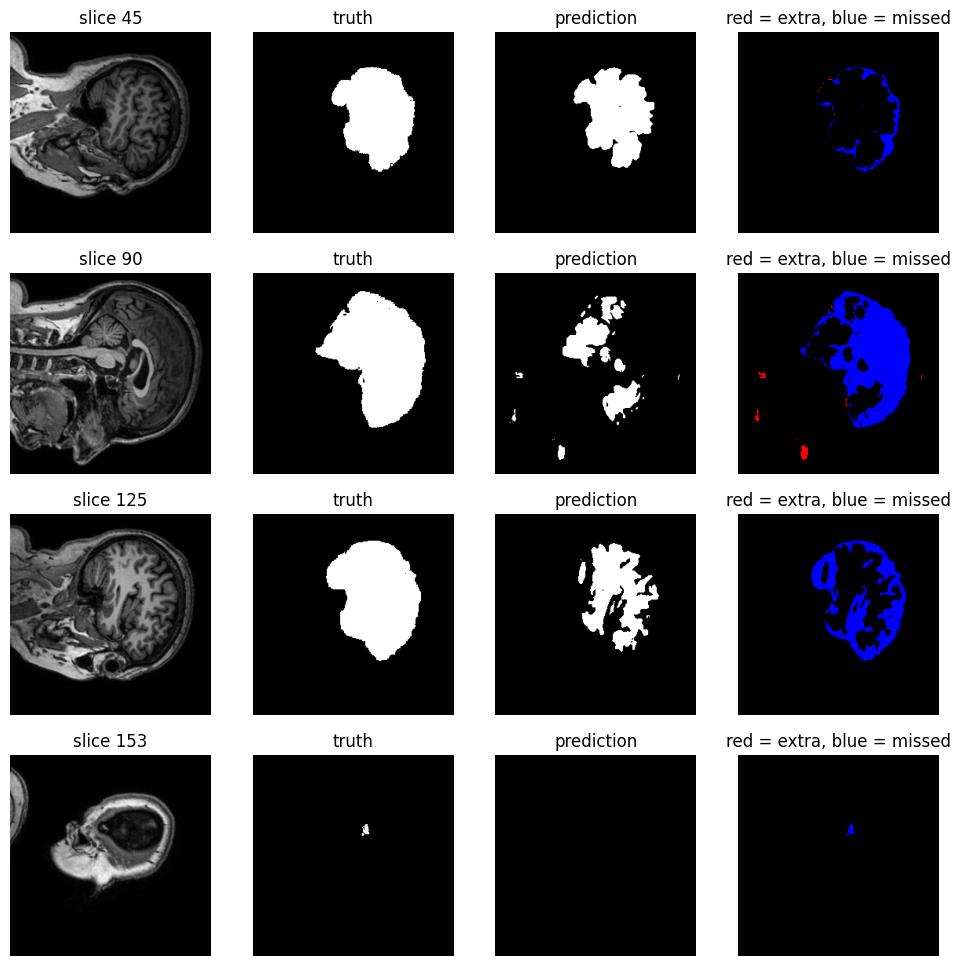

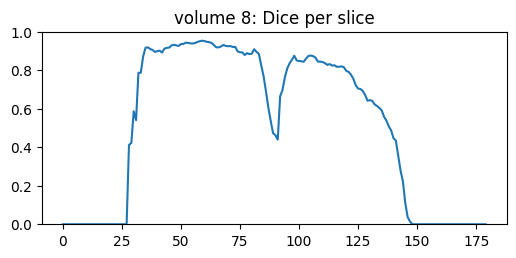

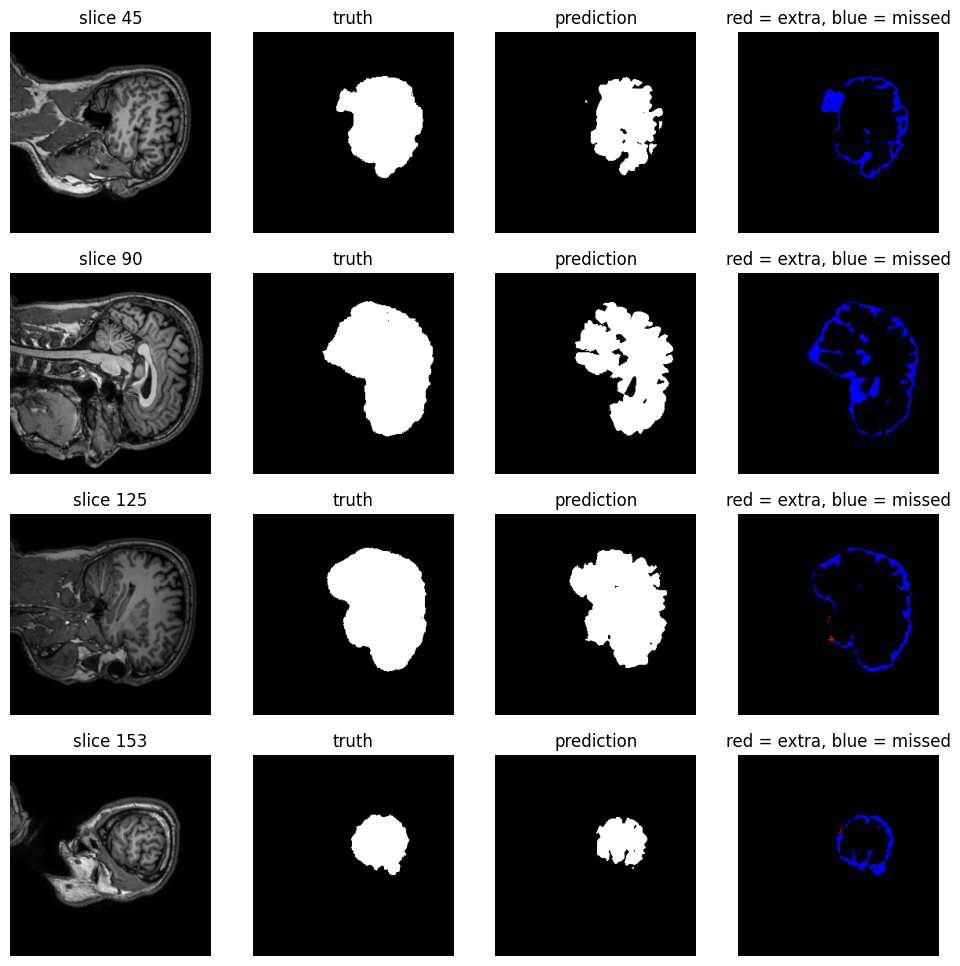

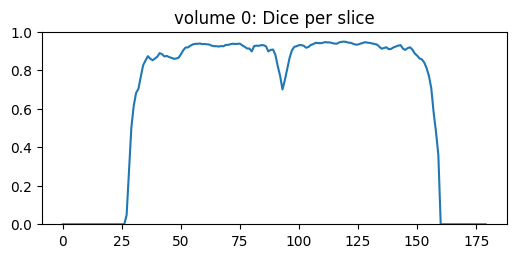

In [29]:
import matplotlib.pyplot as plt

weights_dann = "/kaggle/input/datasets/gurliv22/dann-0-3-last-pth/dann_0.3_last.pth"

net = UNet(in_channels=1, out_channels=1).to(device)
net.load_state_dict(torch.load(weights_dann, map_location=device)); net.eval()


def predict_volume(ds, vi):
    idxs = [k for k, (i, s) in enumerate(ds.items) if i == vi]
    X = torch.stack([ds[k][0] for k in idxs]); Y = torch.stack([ds[k][1] for k in idxs])
    with torch.no_grad():
        P = torch.cat([(torch.sigmoid(net(X[j:j+16].to(device))).cpu() > 0.5).float() for j in range(0, len(X), 16)])
    return X, Y, P

for vi in (8, 0):                      # worst scan (0.822) and a typical one
    X, Y, P = predict_volume(tgt_test_ds, vi)
    n = len(X)
    sl = [(2*(P[s]*Y[s]).sum() / (P[s].sum() + Y[s].sum() + 1e-8)).item() for s in range(n)]
    fig, ax = plt.subplots(4, 4, figsize=(12, 12))
    for r, s in enumerate([int(n*0.25), int(n*0.5), int(n*0.7), int(n*0.85)]):
        ax[r,0].imshow(X[s,0], cmap="gray"); ax[r,0].set_title(f"slice {s}")
        ax[r,1].imshow(Y[s,0], cmap="gray"); ax[r,1].set_title("truth")
        ax[r,2].imshow(P[s,0], cmap="gray"); ax[r,2].set_title("prediction")
        err = np.zeros((*Y[s,0].shape, 3))
        err[..., 0] = ((P[s,0] == 1) & (Y[s,0] == 0)).numpy()
        err[..., 2] = ((P[s,0] == 0) & (Y[s,0] == 1)).numpy()
        ax[r,3].imshow(err); ax[r,3].set_title("red = extra, blue = missed")
        for a in ax[r]: a.axis("off")
    plt.show()
    plt.figure(figsize=(6, 2.5)); plt.plot(sl); plt.ylim(0, 1)
    plt.title(f"volume {vi}: Dice per slice"); plt.show()

In [30]:
from scipy import ndimage as ndi

weights_dann = "/kaggle/input/datasets/gurliv22/dann-0-3-last-pth/dann_0.3_last.pth"

@torch.no_grad()
def evaluate_pp(model, ds, device, bs=16, thr=0.5, postprocess=True):
    model.eval(); by_vol = {}
    for k, (i, s) in enumerate(ds.items): by_vol.setdefault(i, []).append(k)
    dices = []
    for i, idxs in by_vol.items():
        P, G = [], []
        for j in range(0, len(idxs), bs):
            b = [ds[k] for k in idxs[j:j+bs]]
            G.append(torch.stack([t[1] for t in b]))
            P.append((torch.sigmoid(model(torch.stack([t[0] for t in b]).to(device))).cpu() > thr).float())
        p = torch.cat(P)[:, 0].numpy() > 0.5
        g = torch.cat(G)[:, 0].numpy() > 0.5
        if postprocess:
            lab, n = ndi.label(p)
            if n > 1:
                sizes = ndi.sum(p, lab, range(1, n + 1))
                p = lab == (1 + int(np.argmax(sizes)))
            p = ndi.binary_fill_holes(p)
        dices.append(2 * (p & g).sum() / (p.sum() + g.sum() + 1e-8))
    return round(float(np.mean(dices)), 4), round(float(np.std(dices)), 4)

net = UNet(in_channels=1, out_channels=1).to(device)
net.load_state_dict(torch.load(weights_dann, map_location=device))
print("DANN raw:", evaluate_pp(net, tgt_test_ds, device, postprocess=False))
print("DANN +pp:", evaluate_pp(net, tgt_test_ds, device, postprocess=True))

DANN raw: (0.8976, 0.0321)
DANN +pp: (0.8996, 0.0327)


In [31]:
@torch.no_grad()
def size_ratio(model, ds, bs=16):
    model.eval(); by_vol = {}
    for k, (i, s) in enumerate(ds.items): by_vol.setdefault(i, []).append(k)
    r = []
    for i, idxs in by_vol.items():
        p = g = 0.0
        for j in range(0, len(idxs), bs):
            b = [ds[k] for k in idxs[j:j+bs]]
            p += (torch.sigmoid(model(torch.stack([t[0] for t in b]).to(device))).cpu() > 0.5).sum().item()
            g += torch.stack([t[1] for t in b]).sum().item()
        r.append(round(p / g, 3))
    return r

print("Philips:", size_ratio(net, tgt_test_ds))
print("GE:     ", size_ratio(net, src_test_ds))

Philips: [0.836, 0.865, 0.89, 0.836, 0.775, 0.847, 0.796, 0.845, 0.704]
GE:      [0.99, 1.003, 1.0, 1.002, 1.003, 1.013]


In [32]:
import math, random
from torch.utils.data import Subset

weights_dir = "/kaggle/input/datasets/gurliv22/output/src_only_best.pth"
SRC_DICE, ORACLE_DICE = 0.8433, 0.9825

class ImgOnly(Dataset):
    def __init__(self, ds): self.ds = ds
    def __len__(self): return len(self.ds)
    def __getitem__(self, i): return self.ds[i][0]

def match_hist(src, ref):                      
    s, r = src.flatten(1), ref.flatten(1)
    out = torch.empty_like(s)
    out.scatter_(1, s.argsort(1), r.sort(1).values)
    return out.view_as(src)

def run_adapt(name, lam, epochs=6, lr=1e-4, seed=42, sub=2, aug=False):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    net = UNet(in_channels=1, out_channels=1).to(device)
    net.load_state_dict(torch.load(weights_dir, map_location=device))
    dh = DomainHead(channels=(256, 512, 256), alpha=1.0).to(device)
    opt = torch.optim.Adam(list(net.parameters()) + list(dh.parameters()), lr=lr)
    scaler = torch.amp.GradScaler("cuda")
    dom_crit = nn.BCEWithLogitsLoss()

    src_loader = DataLoader(Subset(src_train_ds, range(0, len(src_train_ds), sub)),
                            batch_size=8, shuffle=True, drop_last=True, num_workers=2)
    tgt_loader = DataLoader(Subset(ImgOnly(tgt_train_ds), range(0, len(tgt_train_ds), sub)),
                            batch_size=8, shuffle=True, drop_last=True, num_workers=2)

    for ep in range(epochs):
        dh.grl.alpha = 2 / (1 + math.exp(-10 * ep / max(epochs - 1, 1))) - 1
        net.train(); dh.train()
        tgt_iter = iter(tgt_loader)
        t_seg = t_dom = t_acc = 0.0; n = 0
        for xs, ys in src_loader:
            try: xt = next(tgt_iter)
            except StopIteration:
                tgt_iter = iter(tgt_loader); xt = next(tgt_iter)
            xs, ys, xt = xs.to(device), ys.to(device), xt.to(device)

            if aug:  
                m = torch.rand(xs.size(0), 1, 1, 1, device=device) < 0.7
                xs = torch.where(m, match_hist(xs, xt), xs)
                xs = xs * (1 + 0.1 * torch.randn(xs.size(0), 1, 1, 1, device=device)) \
                        + 0.1 * torch.randn(xs.size(0), 1, 1, 1, device=device)

            opt.zero_grad(set_to_none=True)
            with torch.autocast("cuda", dtype=torch.float16):
                out_s, fs = net(xs, return_features=True)
                _, ft = net(xt, return_features=True)
                ps, pt = dh(fs), dh(ft)
            seg = seg_loss(out_s.float(), ys)
            dom = domain_loss_fn([p.float() for p in ps], [p.float() for p in pt], dom_crit)
            loss = seg + lam * dom
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(list(net.parameters()) + list(dh.parameters()), 1.0)
            scaler.step(opt); scaler.update()
            with torch.no_grad():
                acc = torch.stack([((torch.sigmoid(a.float()) < 0.5).float().mean() +
                                    (torch.sigmoid(b.float()) >= 0.5).float().mean()) / 2
                                   for a, b in zip(ps, pt)]).mean().item()
            t_seg += seg.item(); t_dom += dom.item(); t_acc += acc; n += 1
        print(f"[{name}] epoch {ep+1}/{epochs} | seg {t_seg/n:.4f} | dom {t_dom/n:.4f} | "
              f"dom_acc {t_acc/n:.3f} | alpha {dh.grl.alpha:.2f}")

    torch.save(net.state_dict(), f"/kaggle/working/{name}_last.pth")
    r_s = evaluate_volumes(net, src_test_ds, device)
    r_t = evaluate_volumes(net, tgt_test_ds, device)
    closed = (r_t["dice"] - SRC_DICE) / (ORACLE_DICE - SRC_DICE)
    print(f"[{name}] GE Dice {r_s['dice']:.4f} | Philips Dice {r_t['dice']:.4f} ± {r_t['dice_std']:.4f} | gap closed {closed*100:.1f}%")
    return net, r_s, r_t

hm_net, hm_s, hm_t = run_adapt("dann_hm_s42", lam=0.3, epochs=8, aug=True)

[dann_hm_s42] epoch 1/8 | seg 0.5251 | dom 0.5731 | dom_acc 0.675 | alpha 0.00
[dann_hm_s42] epoch 2/8 | seg 0.2654 | dom 0.5501 | dom_acc 0.692 | alpha 0.61
[dann_hm_s42] epoch 3/8 | seg 0.2115 | dom 0.6100 | dom_acc 0.648 | alpha 0.89
[dann_hm_s42] epoch 4/8 | seg 0.1819 | dom 0.6097 | dom_acc 0.649 | alpha 0.97
[dann_hm_s42] epoch 5/8 | seg 0.1659 | dom 0.6155 | dom_acc 0.640 | alpha 0.99
[dann_hm_s42] epoch 6/8 | seg 0.1585 | dom 0.6139 | dom_acc 0.641 | alpha 1.00
[dann_hm_s42] epoch 7/8 | seg 0.1465 | dom 0.6262 | dom_acc 0.629 | alpha 1.00
[dann_hm_s42] epoch 8/8 | seg 0.1350 | dom 0.6341 | dom_acc 0.620 | alpha 1.00


NameError: name 'evaluate_volumes' is not defined

In [38]:
net = UNet(in_channels=1, out_channels=1).to(device)
net.load_state_dict(torch.load("/kaggle/working/dann_hm_s42_last.pth", map_location=device))

r_s = evaluate_volumes(net, src_test_ds, device)
r_t = evaluate_volumes(net, tgt_test_ds, device)
closed = (r_t["dice"] - 0.8433) / (0.9825 - 0.8433)
print(f"GE Dice {r_s['dice']:.4f} | Philips Dice {r_t['dice']:.4f} ± {r_t['dice_std']:.4f} | gap closed {closed*100:.1f}%")
print("Philips size ratios:", size_ratio(net, tgt_test_ds))   
print("Philips per scan:  ", per_volume_dice(net, tgt_test_ds))

GE Dice 0.9828 | Philips Dice 0.9401 ± 0.0146 | gap closed 69.5%
Philips size ratios: [0.907, 0.941, 0.957, 0.906, 0.9, 0.902, 0.965, 0.93, 0.89]
Philips per scan:   [0.935, 0.949, 0.962, 0.938, 0.932, 0.93, 0.965, 0.929, 0.921]


In [39]:
hm_net, hm_s, hm_t = run_adapt("hm_only_s42", lam=0.0, epochs=8, aug=True)

[hm_only_s42] epoch 1/8 | seg 0.5249 | dom 0.6937 | dom_acc 0.500 | alpha 0.00
[hm_only_s42] epoch 2/8 | seg 0.2652 | dom 0.6938 | dom_acc 0.500 | alpha 0.61
[hm_only_s42] epoch 3/8 | seg 0.2047 | dom 0.6937 | dom_acc 0.503 | alpha 0.89
[hm_only_s42] epoch 4/8 | seg 0.1828 | dom 0.6936 | dom_acc 0.503 | alpha 0.97
[hm_only_s42] epoch 5/8 | seg 0.1603 | dom 0.6935 | dom_acc 0.504 | alpha 0.99
[hm_only_s42] epoch 6/8 | seg 0.1422 | dom 0.6935 | dom_acc 0.505 | alpha 1.00
[hm_only_s42] epoch 7/8 | seg 0.1342 | dom 0.6935 | dom_acc 0.504 | alpha 1.00
[hm_only_s42] epoch 8/8 | seg 0.1272 | dom 0.6935 | dom_acc 0.504 | alpha 1.00
[hm_only_s42] GE Dice 0.9827 | Philips Dice 0.9381 ± 0.0153 | gap closed 68.1%


In [40]:
hm_net, hm_s, hm_t=run_adapt("hm_only_s43", lam=0.0, epochs=8, aug=True, seed=43)

[hm_only_s43] epoch 1/8 | seg 0.5450 | dom 0.6944 | dom_acc 0.497 | alpha 0.00
[hm_only_s43] epoch 2/8 | seg 0.2667 | dom 0.6944 | dom_acc 0.500 | alpha 0.61
[hm_only_s43] epoch 3/8 | seg 0.2029 | dom 0.6942 | dom_acc 0.500 | alpha 0.89
[hm_only_s43] epoch 4/8 | seg 0.1676 | dom 0.6942 | dom_acc 0.499 | alpha 0.97
[hm_only_s43] epoch 5/8 | seg 0.1474 | dom 0.6940 | dom_acc 0.498 | alpha 0.99
[hm_only_s43] epoch 6/8 | seg 0.1343 | dom 0.6940 | dom_acc 0.497 | alpha 1.00
[hm_only_s43] epoch 7/8 | seg 0.1329 | dom 0.6939 | dom_acc 0.499 | alpha 1.00
[hm_only_s43] epoch 8/8 | seg 0.1274 | dom 0.6938 | dom_acc 0.499 | alpha 1.00
[hm_only_s43] GE Dice 0.9834 | Philips Dice 0.9243 ± 0.0162 | gap closed 58.2%


In [41]:
@torch.no_grad()
def evaluate_ens(paths, ds, bs=16, thr=0.5):
    nets = []
    for p in paths:
        m = UNet(in_channels=1, out_channels=1).to(device)
        m.load_state_dict(torch.load(p, map_location=device)); m.eval(); nets.append(m)
    by_vol = {}
    for k, (i, s) in enumerate(ds.items): by_vol.setdefault(i, []).append(k)
    dices = []
    for i, idxs in by_vol.items():
        P, G = [], []
        for j in range(0, len(idxs), bs):
            b = [ds[k] for k in idxs[j:j+bs]]
            x = torch.stack([t[0] for t in b]).to(device)
            G.append(torch.stack([t[1] for t in b]))
            P.append(torch.stack([torch.sigmoid(m(x)).cpu() for m in nets]).mean(0))
        p = (torch.cat(P) > thr).float(); g = torch.cat(G)
        dices.append(2 * (p * g).sum().item() / (p.sum().item() + g.sum().item() + 1e-8))
    return round(float(np.mean(dices)), 4), round(float(np.std(dices)), 4)

paths = ["/kaggle/working/hm_only_s42_last.pth", "/kaggle/working/hm_only_s43_last.pth"]
print("Ensemble Philips:", evaluate_ens(paths, tgt_test_ds))
print("Ensemble GE:     ", evaluate_ens(paths, src_test_ds))

Ensemble Philips: (0.9314, 0.0155)
Ensemble GE:      (0.9832, 0.0028)


In [42]:
hm_net, hm_s, hm_t =run_adapt("hm_only_s44", lam=0.0, epochs=8, aug=True, seed=44)

[hm_only_s44] epoch 1/8 | seg 0.5248 | dom 0.6945 | dom_acc 0.504 | alpha 0.00
[hm_only_s44] epoch 2/8 | seg 0.2653 | dom 0.6945 | dom_acc 0.502 | alpha 0.61
[hm_only_s44] epoch 3/8 | seg 0.2112 | dom 0.6945 | dom_acc 0.502 | alpha 0.89
[hm_only_s44] epoch 4/8 | seg 0.1704 | dom 0.6945 | dom_acc 0.501 | alpha 0.97
[hm_only_s44] epoch 5/8 | seg 0.1541 | dom 0.6944 | dom_acc 0.502 | alpha 0.99
[hm_only_s44] epoch 6/8 | seg 0.1401 | dom 0.6944 | dom_acc 0.502 | alpha 1.00
[hm_only_s44] epoch 7/8 | seg 0.1298 | dom 0.6944 | dom_acc 0.502 | alpha 1.00
[hm_only_s44] epoch 8/8 | seg 0.1293 | dom 0.6944 | dom_acc 0.502 | alpha 1.00
[hm_only_s44] GE Dice 0.9835 | Philips Dice 0.9147 ± 0.0184 | gap closed 51.3%


In [ ]:
#prediction-space adversarial adaptation

In [43]:
class OutputDiscriminator(nn.Module):
    """
    Discriminator operates on segmentation predictions,
    NOT on encoder features.

    Input:  [B, 1, H, W]
    Output: [B, 1, H, W] domain logits
    """
    def __init__(self, in_channels=1):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, kernel_size=4, stride=2, padding=1)
        )

    def forward(self, x):
        return self.net(x)

In [46]:
def run_adaptseg(
    name,
    epochs=8,
    lr=1e-4,
    d_lr=1e-4,
    adv_weight=0.001,
    seed=42,
    sub=2,
    aug=True,
    start_path="/kaggle/working/hm_only_s42_last.pth"
):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    net = UNet(in_channels=1, out_channels=1).to(device)
    net.load_state_dict(torch.load(start_path, map_location=device))

    disc = OutputDiscriminator(in_channels=1).to(device)

    # Separate optimizers
    opt_g = torch.optim.Adam(net.parameters(), lr=lr)
    opt_d = torch.optim.Adam(disc.parameters(), lr=d_lr)

    scaler = torch.amp.GradScaler("cuda")

    adv_criterion = nn.BCEWithLogitsLoss()

    src_loader = DataLoader(
        Subset(
            src_train_ds,
            range(0, len(src_train_ds), sub)
        ),
        batch_size=8,
        shuffle=True,
        drop_last=True,
        num_workers=0
    )

    tgt_loader = DataLoader(
        Subset(
            ImgOnly(tgt_train_ds),
            range(0, len(tgt_train_ds), sub)
        ),
        batch_size=8,
        shuffle=True,
        drop_last=True,
        num_workers=0
    )

    for ep in range(epochs):

        net.train()
        disc.train()

        tgt_iter = iter(tgt_loader)

        t_seg = 0.0
        t_d = 0.0
        t_adv = 0.0
        n = 0

        for xs, ys in src_loader:

            try:
                xt = next(tgt_iter)
            except StopIteration:
                tgt_iter = iter(tgt_loader)
                xt = next(tgt_iter)

            xs = xs.to(device)
            ys = ys.to(device)
            xt = xt.to(device)

            if aug:

                m = (
                    torch.rand(
                        xs.size(0), 1, 1, 1,
                        device=device
                    ) < 0.7
                )

                xs = torch.where(
                    m,
                    match_hist(xs, xt),
                    xs
                )

                xs = (
                    xs *
                    (
                        1 +
                        0.1 * torch.randn(
                            xs.size(0), 1, 1, 1,
                            device=device
                        )
                    )
                    +
                    0.1 * torch.randn(
                        xs.size(0), 1, 1, 1,
                        device=device
                    )
                )


            opt_d.zero_grad(set_to_none=True)

            with torch.no_grad():

                pred_s = torch.sigmoid(
                    net(xs)
                )

                pred_t = torch.sigmoid(
                    net(xt)
                )

            with torch.autocast(
                "cuda",
                dtype=torch.float16
            ):

                d_src = disc(pred_s)
                d_tgt = disc(pred_t)

                loss_d_src = adv_criterion(
                    d_src.float(),
                    torch.zeros_like(d_src).float()
                )

                loss_d_tgt = adv_criterion(
                    d_tgt.float(),
                    torch.ones_like(d_tgt).float()
                )

                loss_d = (
                    loss_d_src +
                    loss_d_tgt
                ) / 2

            scaler.scale(loss_d).backward()
            scaler.step(opt_d)
            scaler.update()

            opt_g.zero_grad(set_to_none=True)

            with torch.autocast(
                "cuda",
                dtype=torch.float16
            ):

                # Source segmentation
                out_s = net(xs)

                # Target prediction
                out_t = net(xt)

                # Supervised source loss
                loss_seg = seg_loss(
                    out_s.float(),
                    ys
                )

                pred_t = torch.sigmoid(out_t)

                d_tgt_for_g = disc(pred_t)

                loss_adv = adv_criterion(
                    d_tgt_for_g.float(),
                    torch.zeros_like(
                        d_tgt_for_g
                    ).float()
                )

                loss_g = (
                    loss_seg +
                    adv_weight * loss_adv
                )

            scaler.scale(loss_g).backward()

            scaler.unscale_(opt_g)

            torch.nn.utils.clip_grad_norm_(
                net.parameters(),
                1.0
            )

            scaler.step(opt_g)
            scaler.update()

            with torch.no_grad():

                src_acc = (
                    (
                        torch.sigmoid(d_src.float()) < 0.5
                    ).float().mean()
                )

                tgt_acc = (
                    (
                        torch.sigmoid(d_tgt.float()) >= 0.5
                    ).float().mean()
                )

                d_acc = (
                    (src_acc + tgt_acc) / 2
                ).item()

            t_seg += loss_seg.item()
            t_d += loss_d.item()
            t_adv += loss_adv.item()

            n += 1

        print(
            f"[{name}] epoch {ep+1}/{epochs} | "
            f"seg {t_seg/n:.4f} | "
            f"D {t_d/n:.4f} | "
            f"adv {t_adv/n:.4f} | "
            f"D_acc {d_acc:.3f}"
        )

    save_path = f"/kaggle/working/{name}_last.pth"

    torch.save(
        net.state_dict(),
        save_path
    )

    r_s = evaluate_volumes(
        net,
        src_test_ds,
        device
    )

    r_t = evaluate_volumes(
        net,
        tgt_test_ds,
        device
    )

    closed = (
        r_t["dice"] - SRC_DICE
    ) / (
        ORACLE_DICE - SRC_DICE
    )

    print(
        f"[{name}] "
        f"GE Dice {r_s['dice']:.4f} | "
        f"Philips Dice {r_t['dice']:.4f} "
        f"± {r_t['dice_std']:.4f} | "
        f"gap closed {closed*100:.1f}%"
    )

    return net, r_s, r_t

In [47]:
adaptseg_net, adaptseg_s, adaptseg_t = run_adaptseg(
    name="adaptseg_hm_s42",
    epochs=8,
    adv_weight=0.001,
    seed=42,
    aug=True,
    start_path="/kaggle/working/hm_only_s42_last.pth"
)

[adaptseg_hm_s42] epoch 1/8 | seg 0.1162 | D 0.5482 | adv 1.1116 | D_acc 0.577
[adaptseg_hm_s42] epoch 2/8 | seg 0.1130 | D 0.3940 | adv 1.7600 | D_acc 0.995
[adaptseg_hm_s42] epoch 3/8 | seg 0.1183 | D 0.4100 | adv 1.7960 | D_acc 0.996
[adaptseg_hm_s42] epoch 4/8 | seg 0.1093 | D 0.4133 | adv 1.8051 | D_acc 0.597
[adaptseg_hm_s42] epoch 5/8 | seg 0.1013 | D 0.4309 | adv 1.7203 | D_acc 0.931
[adaptseg_hm_s42] epoch 6/8 | seg 0.0935 | D 0.4551 | adv 1.6237 | D_acc 0.952
[adaptseg_hm_s42] epoch 7/8 | seg 0.0998 | D 0.4653 | adv 1.5547 | D_acc 0.981
[adaptseg_hm_s42] epoch 8/8 | seg 0.0868 | D 0.4152 | adv 1.7344 | D_acc 0.547
[adaptseg_hm_s42] GE Dice 0.9844 | Philips Dice 0.9565 ± 0.0093 | gap closed 81.3%


In [49]:
adaptseg_net, adaptseg_s, adaptseg_t = run_adaptseg(
    name="adaptseg_hm_s42_control",
    epochs=8,
    adv_weight=0.0,
    seed=42,
    aug=True,
    start_path="/kaggle/working/hm_only_s42_last.pth"
)

[adaptseg_hm_s42_control] epoch 1/8 | seg 0.1186 | D 0.5403 | adv 1.1200 | D_acc 0.546
[adaptseg_hm_s42_control] epoch 2/8 | seg 0.1123 | D 0.3346 | adv 2.0786 | D_acc 0.993
[adaptseg_hm_s42_control] epoch 3/8 | seg 0.1175 | D 0.2875 | adv 2.4678 | D_acc 1.000
[adaptseg_hm_s42_control] epoch 4/8 | seg 0.1073 | D 0.2365 | adv 2.9101 | D_acc 0.990
[adaptseg_hm_s42_control] epoch 5/8 | seg 0.0996 | D 0.2282 | adv 2.9666 | D_acc 0.996
[adaptseg_hm_s42_control] epoch 6/8 | seg 0.0953 | D 0.2344 | adv 3.0864 | D_acc 0.746
[adaptseg_hm_s42_control] epoch 7/8 | seg 0.0983 | D 0.2291 | adv 3.2205 | D_acc 0.999
[adaptseg_hm_s42_control] epoch 8/8 | seg 0.0862 | D 0.2095 | adv 3.4349 | D_acc 0.985
[adaptseg_hm_s42_control] GE Dice 0.9840 | Philips Dice 0.9386 ± 0.0160 | gap closed 68.5%


In [59]:
adaptseg_net, adaptseg_s, adaptseg_t =run_adaptseg("adaptseg_hm_s43", epochs=8, adv_weight=0.001, seed=43, aug=True,
             start_path="/kaggle/working/hm_only_s43_last.pth")

[adaptseg_hm_s43] epoch 1/8 | seg 0.1213 | D 0.5205 | adv 1.1783 | D_acc 0.590
[adaptseg_hm_s43] epoch 2/8 | seg 0.1106 | D 0.3802 | adv 1.7976 | D_acc 0.991
[adaptseg_hm_s43] epoch 3/8 | seg 0.1076 | D 0.3677 | adv 1.9052 | D_acc 0.581
[adaptseg_hm_s43] epoch 4/8 | seg 0.0986 | D 0.3903 | adv 1.9122 | D_acc 0.704
[adaptseg_hm_s43] epoch 5/8 | seg 0.1006 | D 0.3618 | adv 1.9491 | D_acc 0.954
[adaptseg_hm_s43] epoch 6/8 | seg 0.0945 | D 0.3460 | adv 2.0305 | D_acc 0.993
[adaptseg_hm_s43] epoch 7/8 | seg 0.0915 | D 0.3313 | adv 2.0823 | D_acc 0.990
[adaptseg_hm_s43] epoch 8/8 | seg 0.0887 | D 0.2635 | adv 2.4418 | D_acc 0.972
[adaptseg_hm_s43] GE Dice 0.9842 | Philips Dice 0.9618 ± 0.0076 | gap closed 85.1%


In [83]:
import numpy as np, torch, matplotlib.pyplot as plt

oracle= "/kaggle/input/datasets/gurliv22/output/oracle_best.pth"

def load(path):
    m = UNet(in_channels=1, out_channels=1).to(device)
    m.load_state_dict(torch.load(path, map_location=device))
    return m.eval()

final  = load("/kaggle/working/adaptseg_hm_s43_last.pth")
base   = load(weights_dir)                         
oracle = load(oracle)  

@torch.no_grad()
def predict(model, ds, vi, bs=16):
    idxs = [k for k, (i, s) in enumerate(ds.items) if i == vi]
    X = torch.stack([ds[k][0] for k in idxs]); Y = torch.stack([ds[k][1] for k in idxs])
    P = torch.cat([torch.sigmoid(model(X[j:j+bs].to(device))).cpu() for j in range(0, len(X), bs)])
    return X[:, 0].numpy(), Y[:, 0].numpy() > 0.5, P[:, 0].numpy() > 0.5

def dice(y, p): return 2 * (y & p).sum() / (y.sum() + p.sum() + 1e-8)
def n_vols(ds): return len({i for i, _ in ds.items})
def vol_dices(model, ds): return [dice(*predict(model, ds, v)[1:]) for v in range(n_vols(ds))]

def err_rgb(y, p):
    e = np.zeros((*y.shape, 3))
    e[y & p] = (0.25, 0.75, 0.35)     # green = correct
    e[~y & p] = (0.9, 0.2, 0.2)       # red   = extra (predicted, not brain)
    e[y & ~p] = (0.2, 0.3, 0.95)      # blue  = missed brain
    return e

def pick(Y, q=(0.2, 0.4, 0.6, 0.8)):
    nz = np.where(Y.reshape(len(Y), -1).any(1))[0]
    return [int(nz[int(len(nz) * f)]) for f in q]

def save(name):
    plt.tight_layout(); plt.savefig(f"/kaggle/working/fig_{name}.png", dpi=150, bbox_inches="tight"); plt.show()

def show_volume(model, ds, vi, title, name):
    X, Y, P = predict(model, ds, vi); sl = pick(Y)
    fig, ax = plt.subplots(len(sl), 4, figsize=(13, 3.3 * len(sl)))
    for r, s in enumerate(sl):
        ax[r,0].imshow(X[s], cmap="gray"); ax[r,0].set_title(f"MRI slice {s}")
        ax[r,1].imshow(Y[s], cmap="gray"); ax[r,1].set_title("truth")
        ax[r,2].imshow(P[s], cmap="gray"); ax[r,2].set_title(f"prediction (Dice {dice(Y[s], P[s]):.3f})")
        ax[r,3].imshow(err_rgb(Y[s], P[s])); ax[r,3].set_title("green ok | red extra | blue missed")
        for a in ax[r]: a.axis("off")
    fig.suptitle(f"{title} - scan Dice {dice(Y, P):.4f}")
    save(name)

def before_after(ds, vi, name):
    X, Y, Pb = predict(base, ds, vi); Pf = predict(final, ds, vi)[2]; Po = predict(oracle, ds, vi)[2]
    sl = pick(Y)
    fig, ax = plt.subplots(len(sl), 4, figsize=(13, 3.3 * len(sl)))
    for r, s in enumerate(sl):
        ax[r,0].imshow(X[s], cmap="gray"); ax[r,0].set_title(f"MRI slice {s}")
        for c, (P_, lab) in enumerate([(Pb, "source-only"), (Pf, "final method"), (Po, "oracle")], start=1):
            ax[r,c].imshow(err_rgb(Y[s], P_[s])); ax[r,c].set_title(f"{lab} ({dice(Y[s], P_[s]):.3f})")
        for a in ax[r]: a.axis("off")
    fig.suptitle("Philips 3T: before vs after (green ok | red extra | blue missed)")
    save(name + "_images")
    plt.figure(figsize=(7, 3))
    for P_, lab in [(Pb, "source-only"), (Pf, "final"), (Po, "oracle")]:
        plt.plot([dice(Y[s], P_[s]) if Y[s].any() else np.nan for s in range(len(Y))], label=lab)
    plt.ylim(0, 1); plt.xlabel("slice"); plt.ylabel("Dice"); plt.legend(); plt.title("Dice per slice")
    save(name + "_curve")


def per_volume_bars(name):
    fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
    sets = [(ax[0], src_test_ds, "GE 3T (source) test", [("source-only", base), ("final", final)]),
            (ax[1], tgt_test_ds, "Philips 3T (target) test", [("source-only", base), ("final", final), ("oracle", oracle)])]
    for a, ds, t, models in sets:
        n = n_vols(ds); w = 0.8 / len(models)
        for k, (lab, m) in enumerate(models):
            a.bar(np.arange(n) + k * w, vol_dices(m, ds), w, label=lab)
        a.set_ylim(0.7, 1.0); a.set_title(t); a.set_xlabel("test scan"); a.set_ylabel("Dice"); a.legend()
    save(name)


def summary_bar():
    res = {"Source-only": 0.8433, "Control\n(extra GE\ntraining)": 0.8017, "DANN": 0.8965,
           "Histogram\nmatching": 0.9257, "Matching +\nadversarial": 0.9592, "Oracle": 0.9825}
    plt.figure(figsize=(9, 4)); b = plt.bar(list(res), list(res.values()), color="#4c78a8")
    for r, v in zip(b, res.values()): plt.text(r.get_x() + r.get_width() / 2, v + 0.003, f"{v:.3f}", ha="center")
    plt.ylim(0.75, 1.0); plt.ylabel("Philips 3T test Dice"); plt.title("Philips 3T Dice by method (mean over seeds)")
    save("summary")


def intensity_hist():
    plt.figure(figsize=(6, 3.5))
    for ds, lab in [(src_test_ds, "GE 3T"), (tgt_test_ds, "Philips 3T")]:
        v = np.concatenate([x[x > x.min()][::50] for x in ds.vols]).astype(np.float32)
        plt.hist(v, bins=100, range=(-1, 4), density=True, alpha=0.5, label=lab)
    plt.legend(); plt.xlabel("normalized intensity"); plt.title("Brightness values: GE vs Philips")
    save("intensity")


In [76]:
base_d = vol_dices(base, tgt_test_ds); fin_d = vol_dices(final, tgt_test_ds)


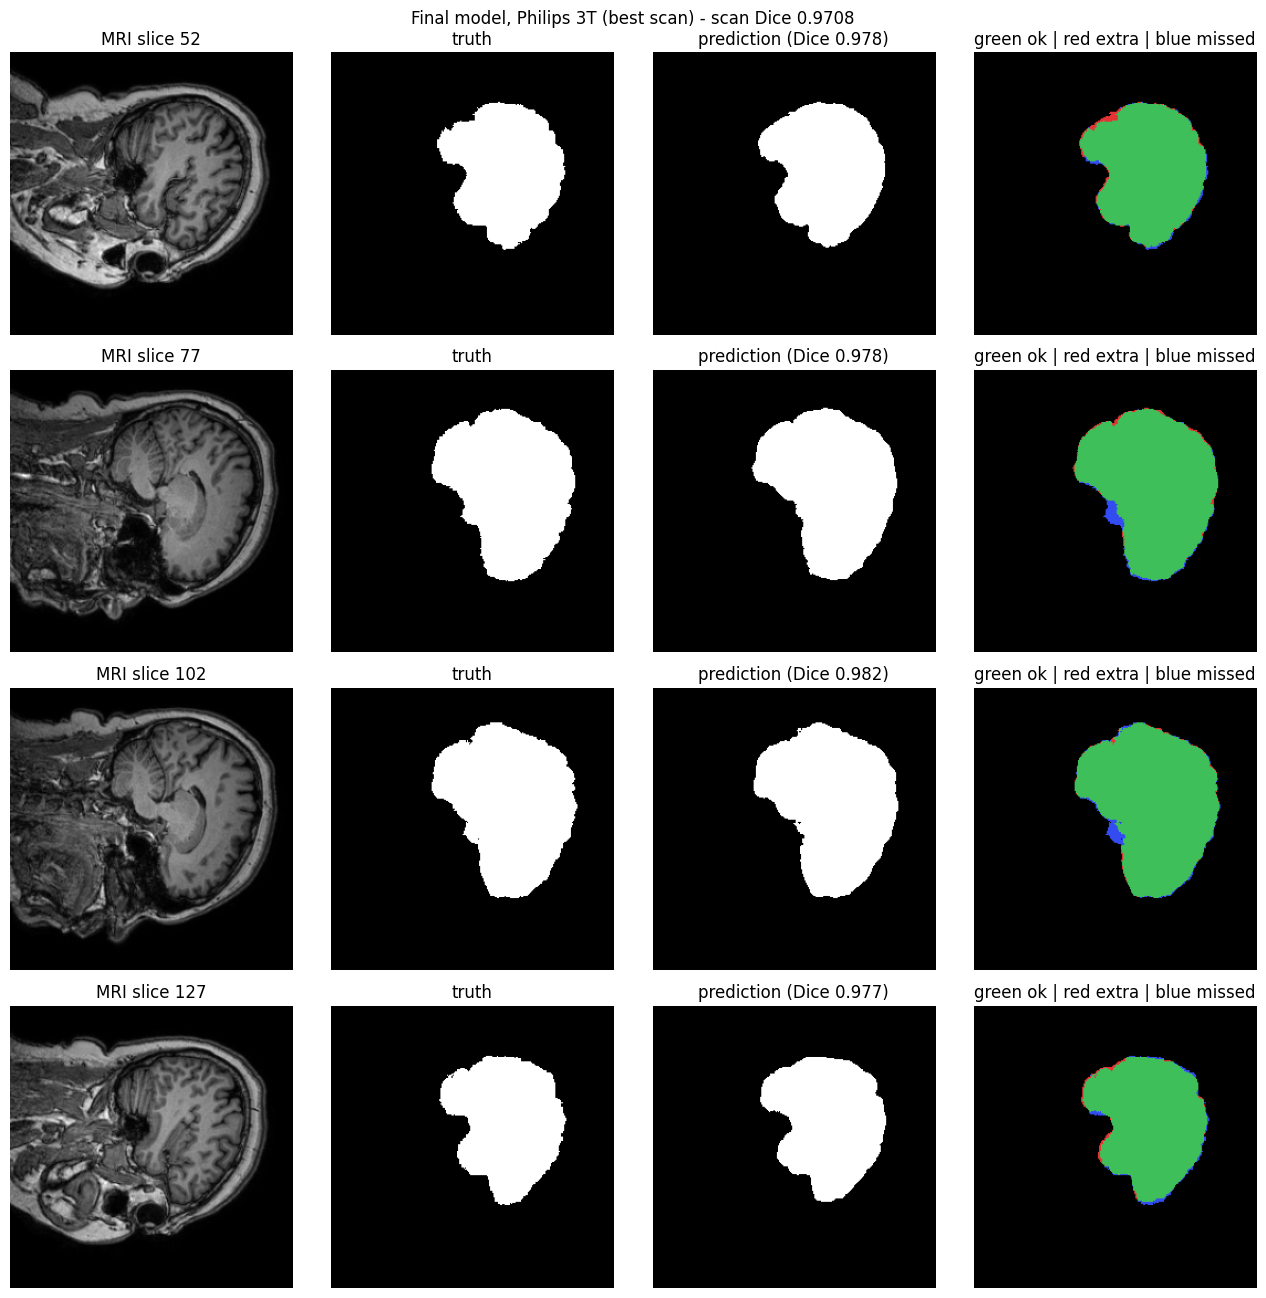

In [77]:
show_volume(final, tgt_test_ds, int(np.argmax(fin_d)), "Final model, Philips 3T (best scan)", "philips_best")


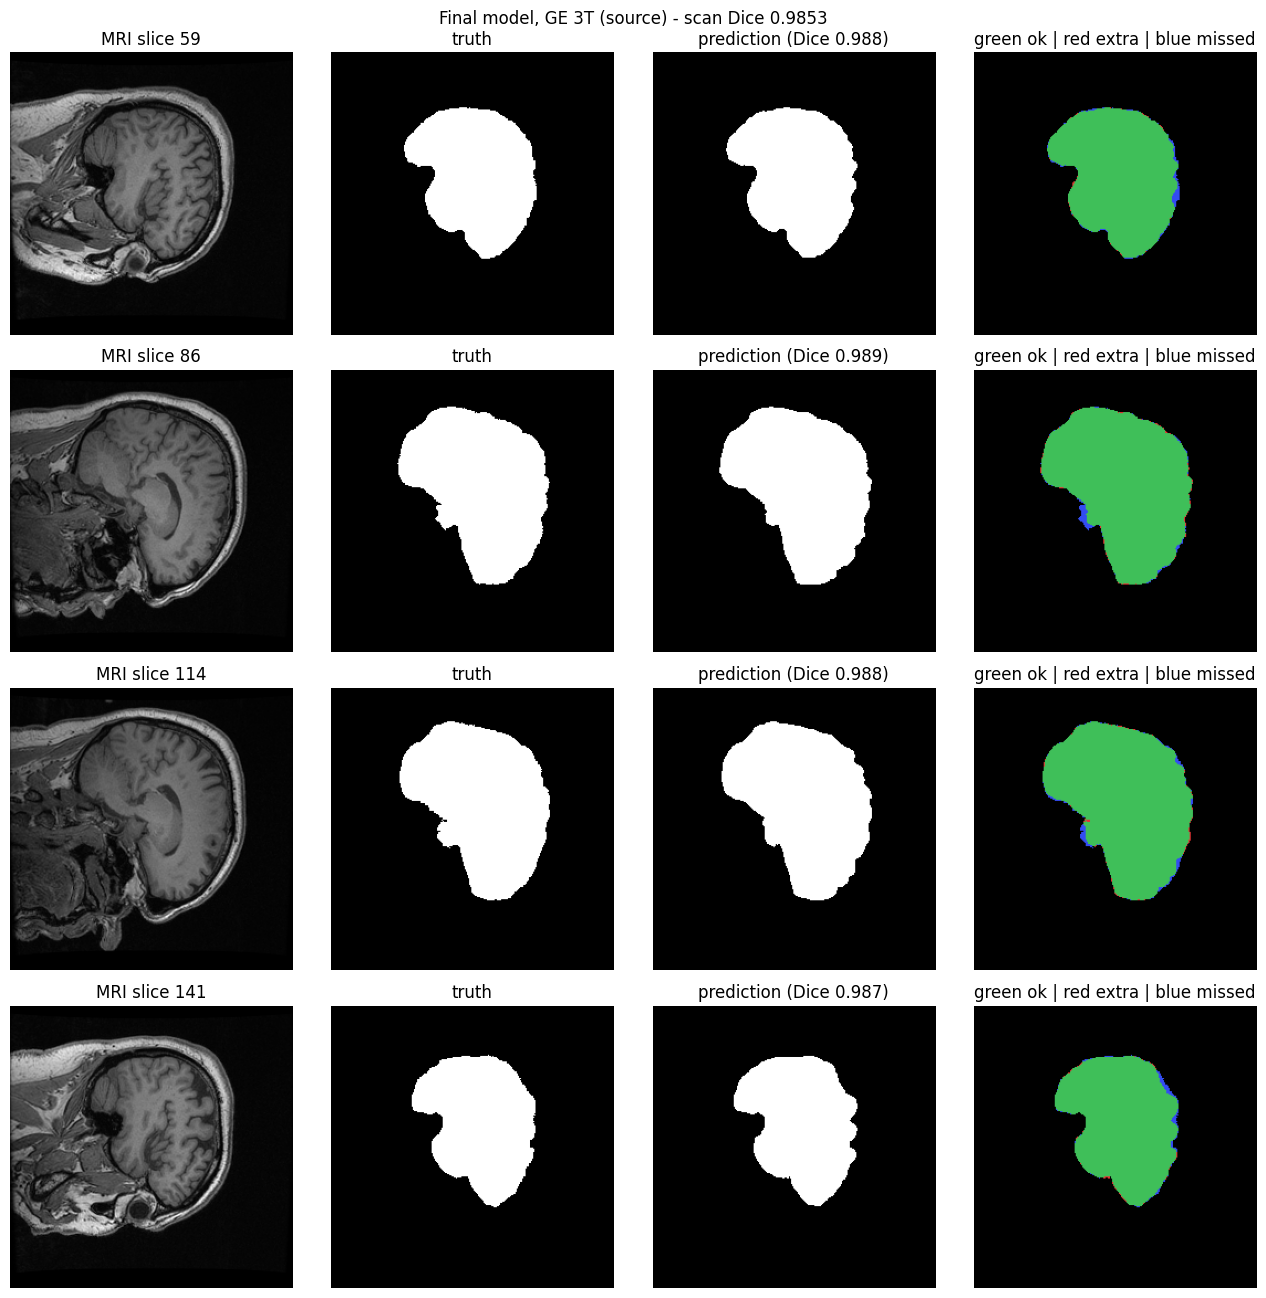

In [79]:
show_volume(final, src_test_ds, 0, "Final model, GE 3T (source)", "ge")


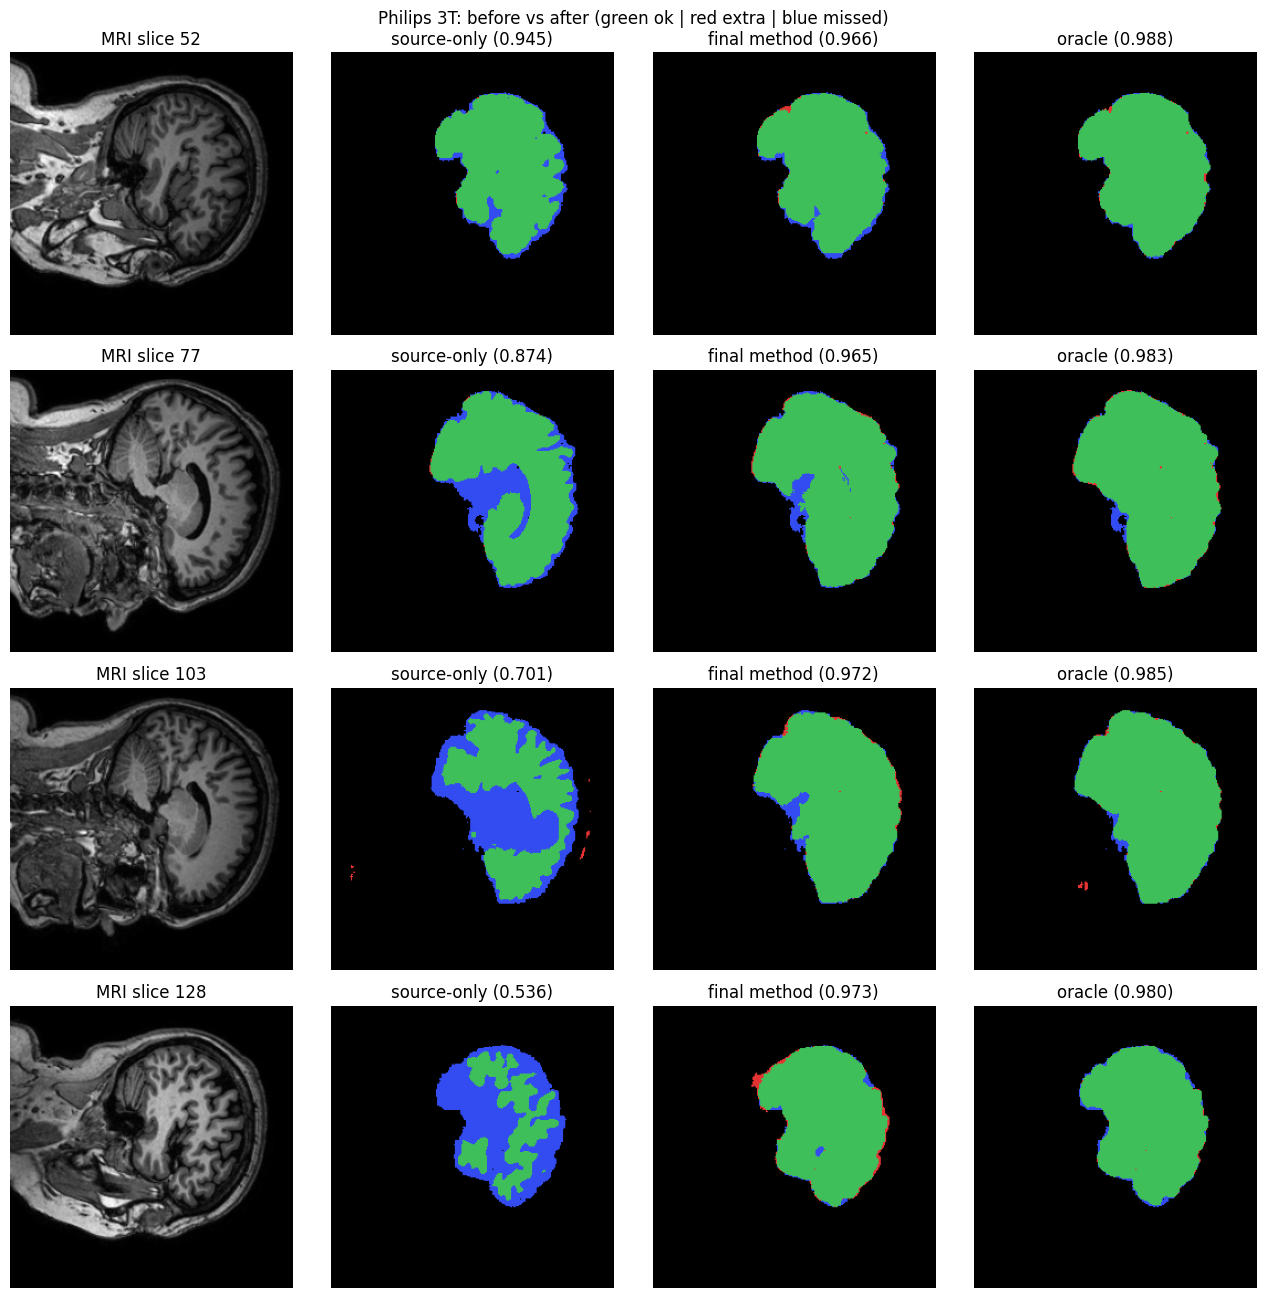

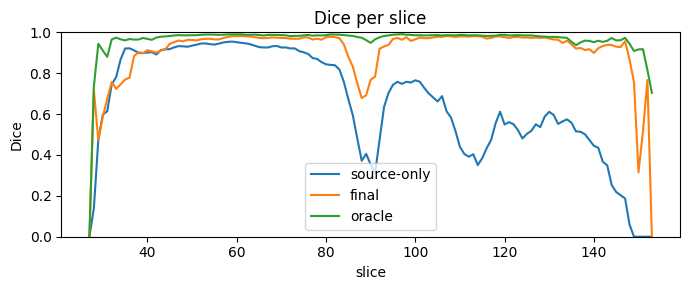

In [80]:
before_after(tgt_test_ds, int(np.argmin(base_d)), "before_after")


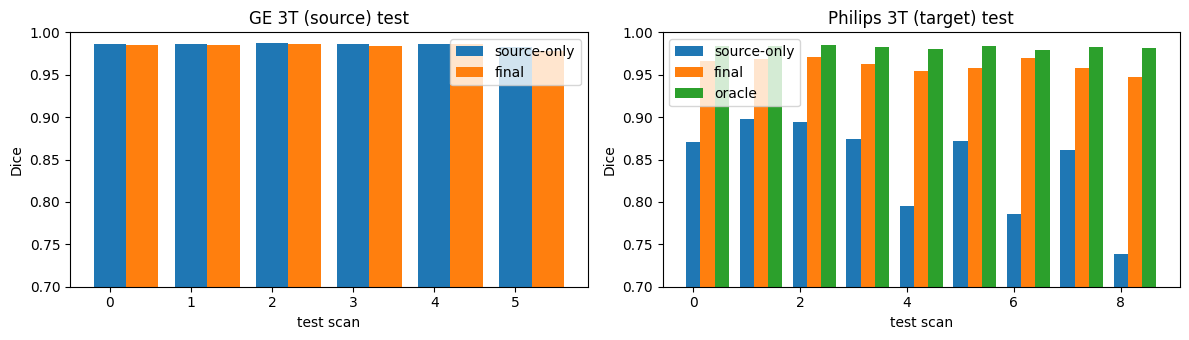

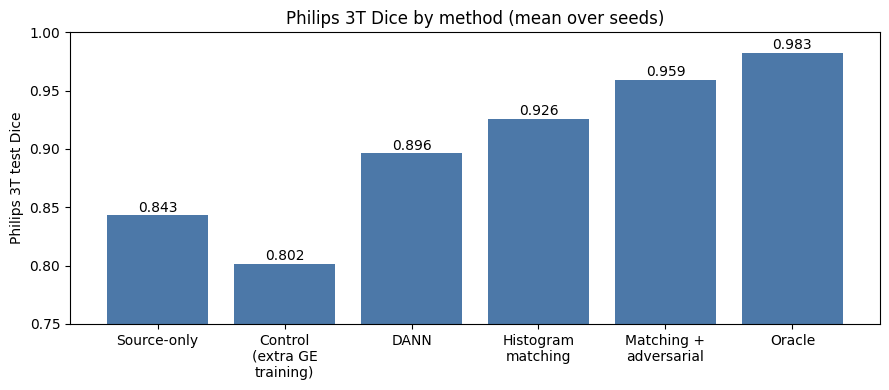

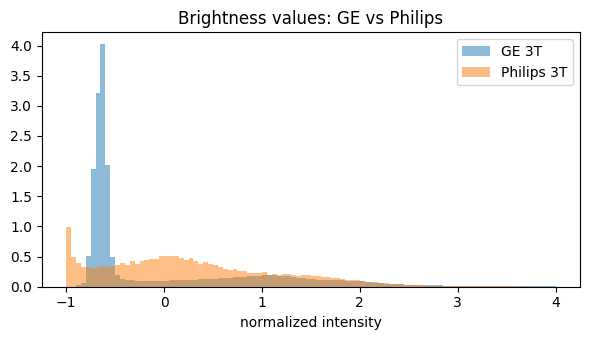

In [81]:
per_volume_bars("per_volume"); summary_bar(); intensity_hist()